In [ ]:
import anywidget
import traitlets
import numpy as np
import xarray as xr

# ==========================================
# 1. AnyWidget Definition
# ==========================================
class NMRSpectraViewer(anywidget.AnyWidget):
    """An interactive canvas-based viewer for NMR spectra."""

    _css = """
    .nmr-wrapper { display: flex; flex-direction: column; align-items: center; font-family: sans-serif; }
    .nmr-canvas { border: 1px solid #ddd; background-color: #fff; cursor: crosshair; }
    .nmr-controls { display: flex; width: 700px; justify-content: space-between; align-items: center; padding: 10px 0; }
    .nmr-slider { flex-grow: 1; margin: 0 15px; cursor: pointer; }
    .nmr-info { font-size: 14px; color: #333; min-width: 120px; text-align: right; }
    """

    _esm = """
    export function render({ model, el }) {
        // Create UI elements
        let wrapper = document.createElement("div");
        wrapper.className = "nmr-wrapper";

        let canvas = document.createElement("canvas");
        canvas.width = 700;
        canvas.height = 350;
        canvas.className = "nmr-canvas";

        let controls = document.createElement("div");
        controls.className = "nmr-controls";

        let traceLabel = document.createElement("label");
        let traceCheck = document.createElement("input");
        traceCheck.type = "checkbox";
        traceCheck.checked = model.get("show_trace");
        traceLabel.appendChild(traceCheck);
        traceLabel.appendChild(document.createTextNode(" Fading Trace"));

        let slider = document.createElement("input");
        slider.type = "range";
        slider.className = "nmr-slider";
        slider.min = 0;

        let infoBox = document.createElement("div");
        infoBox.className = "nmr-info";

        controls.appendChild(traceLabel);
        controls.appendChild(slider);
        controls.appendChild(infoBox);
        wrapper.appendChild(canvas);
        wrapper.appendChild(controls);
        el.appendChild(wrapper);

        let ctx = canvas.getContext("2d");

        function draw() {
            const ppm = model.get("ppm");
            const spectra = model.get("spectra");
            const idx = model.get("current_index");
            const xlim = model.get("xlim");
            const ylim = model.get("ylim");
            const showTrace = model.get("show_trace");

            if (!ppm || !spectra || spectra.length === 0) return;

            slider.max = spectra.length - 1;
            slider.value = idx;
            infoBox.innerText = `Spectrum: ${idx + 1} / ${spectra.length}`;

            // Clear canvas
            ctx.clearRect(0, 0, canvas.width, canvas.height);

            // X-Axis bounds (Standard NMR convention: High to Low ppm)
            let minX = xlim ? xlim[0] : Math.min(...ppm);
            let maxX = xlim ? xlim[1] : Math.max(...ppm);
            let displayMinX = Math.min(minX, maxX);
            let displayMaxX = Math.max(minX, maxX);

            // Y-Axis bounds
            let minY = ylim ? ylim[0] : 0;
            let maxY = ylim ? ylim[1] : 1;
            if (!ylim) {
                // If no ylim provided, fix axis globally to prevent jumping
                minY = Math.min(...spectra.flat());
                maxY = Math.max(...spectra.flat());
                let pad = (maxY - minY) * 0.05;
                minY -= pad;
                maxY += pad;
            }

            const margin = { top: 20, right: 20, bottom: 40, left: 60 };
            const width = canvas.width - margin.left - margin.right;
            const height = canvas.height - margin.top - margin.bottom;

            // Coordinate mappers
            // Maps ppm to X, ensuring high ppm is on the left
            const getX = (val) => margin.left + width * (displayMaxX - val) / (displayMaxX - displayMinX);
            const getY = (val) => margin.top + height - height * (val - minY) / (maxY - minY);

            // Draw Axes
            ctx.strokeStyle = "#000";
            ctx.lineWidth = 1;
            ctx.beginPath();
            ctx.moveTo(margin.left, margin.top);
            ctx.lineTo(margin.left, margin.top + height);
            ctx.lineTo(margin.left + width, margin.top + height);
            ctx.stroke();

            // Draw Labels
            ctx.fillStyle = "#000";
            ctx.font = "12px sans-serif";
            ctx.textAlign = "center";
            ctx.fillText(displayMaxX.toFixed(1), margin.left, margin.top + height + 20);
            ctx.fillText(displayMinX.toFixed(1), margin.left + width, margin.top + height + 20);
            ctx.fillText("Chemical Shift (ppm)", margin.left + width / 2, margin.top + height + 35);

            ctx.textAlign = "right";
            ctx.fillText(maxY.toFixed(1), margin.left - 8, margin.top + 10);
            ctx.fillText(minY.toFixed(1), margin.left - 8, margin.top + height);

            // Helper to draw a single spectrum
            const drawLine = (dataRow, color, alpha, lineWidth) => {
                ctx.beginPath();
                ctx.strokeStyle = color;
                ctx.globalAlpha = alpha;
                ctx.lineWidth = lineWidth;
                let first = true;
                for (let i = 0; i < ppm.length; i++) {
                    let p = ppm[i];
                    if (p < displayMinX || p > displayMaxX) continue; // Clip to xlim
                    let x = getX(p);
                    let y = getY(dataRow[i]);

                    if (y < margin.top) y = margin.top; // Clip to ylim top
                    if (y > margin.top + height) y = margin.top + height; // Clip to ylim bottom

                    if (first) {
                        ctx.moveTo(x, y);
                        first = false;
                    } else {
                        ctx.lineTo(x, y);
                    }
                }
                ctx.stroke();
                ctx.globalAlpha = 1.0;
            };

            // Clip drawing area to not spill over axes
            ctx.save();
            ctx.beginPath();
            ctx.rect(margin.left, margin.top, width, height);
            ctx.clip();

            // Draw Fading Trace
            if (showTrace && idx > 0) {
                drawLine(spectra[idx - 1], "#999", 0.4, 1.5); // Gray, 40% opacity
            }

            // Draw Current Trace
            drawLine(spectra[idx], "#005a9c", 1.0, 2); // Blue, Solid

            ctx.restore();
        }

        // Event Listeners for Model Sync
        model.on("change:current_index", draw);
        model.on("change:show_trace", draw);
        model.on("change:xlim", draw);
        model.on("change:ylim", draw);

        // Control Listeners
        slider.addEventListener("input", (e) => {
            model.set("current_index", parseInt(e.target.value));
            model.save_changes();
        });

        traceCheck.addEventListener("change", (e) => {
            model.set("show_trace", e.target.checked);
            model.save_changes();
        });

        // Mouse Wheel scrolling over canvas
        canvas.addEventListener("wheel", (e) => {
            e.preventDefault(); // Prevents the whole notebook page from scrolling
            let idx = model.get("current_index");
            let spectra = model.get("spectra");
            if (!spectra) return;

            let max_idx = spectra.length - 1;

            if (e.deltaY > 0) {
                idx = Math.min(idx + 1, max_idx);
            } else if (e.deltaY < 0) {
                idx = Math.max(idx - 0, 0); // Handle backward scroll
                idx = Math.max(idx - 1, 0);
            }

            model.set("current_index", idx);
            model.save_changes();
        });

        // Initialize
        setTimeout(draw, 50);
    }
    """

    ppm = traitlets.List().tag(sync=True)
    spectra = traitlets.List().tag(sync=True)
    current_index = traitlets.Int(0).tag(sync=True)
    xlim = traitlets.List(allow_none=True, default_value=None).tag(sync=True)
    ylim = traitlets.List(allow_none=True, default_value=None).tag(sync=True)
    show_trace = traitlets.Bool(True).tag(sync=True)


# ==========================================
# 2. Wrapper Function for Xarray
# ==========================================
def view_spectra(da: xr.DataArray, xlim=None, ylim=None, show_trace=True, part='real'):
    """
    Creates an interactive widget to scroll through an Xarray DataArray of spectra.
    Assumes dimensions are ('time', 'ppm').
    """
    # Identify ppm dimension dynamically
    ppm_dim = next((d for d in da.dims if 'ppm' in str(d).lower()), da.dims[1])
    ppm_vals = da.coords[ppm_dim].values

    # Extract part and handle complex arrays safely
    if part == 'real':
        data_vals = np.real(da.values)
    elif part == 'imag':
        data_vals = np.imag(da.values)
    else:
        raise ValueError("part must be 'real' or 'imag'")

    # Ensure shape is (time, ppm)
    if da.dims[0] == ppm_dim:
        data_vals = data_vals.T

    # Convert to standard Python lists for JSON serialization to frontend
    widget = NMRSpectraViewer(
        ppm=ppm_vals.tolist(),
        spectra=data_vals.tolist(),
        xlim=xlim,
        ylim=ylim,
        show_trace=show_trace
    )
    return widget


# ==========================================
# 3. Dummy Data Generation & Execution
# ==========================================
def create_dummy_mrs_data():
    """Generates a dummy hyperpolarized 13C dataset (complex-valued)."""
    t = np.arange(60) # 60 repetitions
    ppm = np.linspace(200, 10, 1024) # standard 13C ppm range reversed

    # Lorentzian line shape function
    def lorentzian(x, x0, w):
        return w / ((x - x0)**2 + w**2)

    # Simulate kinetics: Pyruvate (171 ppm) decays, Lactate (183 ppm) grows then decays
    pyr_amp = 100 * np.exp(-t / 15)
    lac_amp = 80 * (1 - np.exp(-t / 8)) * np.exp(-t / 30)

    spectra = np.zeros((len(t), len(ppm)), dtype=complex)

    for i in range(len(t)):
        # Real peaks
        real_part = (pyr_amp[i] * lorentzian(ppm, 171, 1.5) +
                     lac_amp[i] * lorentzian(ppm, 183, 1.5))
        # Imaginary peaks (phase twist)
        imag_part = (pyr_amp[i] * (ppm - 171) / ((ppm - 171)**2 + 1.5**2))

        spectra[i] = real_part + 1j * imag_part

    # Add complex noise
    noise = np.random.normal(0, 0.5, spectra.shape) + 1j * np.random.normal(0, 0.5, spectra.shape)
    spectra += noise

    # Package into xarray
    da = xr.DataArray(
        spectra,
        dims=["time", "ppm"],
        coords={"time": t, "ppm": ppm},
        name="Hyperpolarized Signal"
    )
    return da

# Run the demonstration!
dummy_dataset = create_dummy_mrs_data()

# View full spectrum range
# display(view_spectra(dummy_dataset))

# View a zoomed region (specifically targeting Pyruvate and Lactate)
widget = view_spectra(
    dummy_dataset,
    # xlim=[190, 160],   # Zooms into the C1 region
    part='real',       # Can swap to 'imag'
    show_trace=True    # Toggles the fading ghost trace
)
display(widget)

In [ ]:
import anywidget
import traitlets
import numpy as np
import xarray as xr


# ============================================================================
# 1. AnyWidget definition
# ============================================================================
class NMRSpectraViewer(anywidget.AnyWidget):
    """Interactive NMR spectra viewer with mouse-wheel scrolling and fading trace."""

    _esm = """
export function render({ model, el }) {
    const W = 740, H = 400;
    const dpr = window.devicePixelRatio || 1;

    /* ── DOM ── */
    const root = document.createElement("div");
    root.className = "nmr-viewer";

    const canvas = document.createElement("canvas");
    canvas.width = W * dpr;
    canvas.height = H * dpr;
    canvas.style.width  = W + "px";
    canvas.style.height = H + "px";
    canvas.className = "nmr-canvas";
    canvas.tabIndex = 0;
    canvas.title = "Scroll to browse · Arrow keys to step · Space to play/pause";

    /* timeline */
    const tl      = document.createElement("div");  tl.className = "nmr-tl";
    const tlFill  = document.createElement("div");  tlFill.className  = "nmr-tl-fill";
    const tlThumb = document.createElement("div");  tlThumb.className = "nmr-tl-thumb";
    tl.append(tlFill, tlThumb);

    /* controls bar */
    const bar   = document.createElement("div"); bar.className = "nmr-bar";
    const grpL  = document.createElement("div"); grpL.className = "nmr-grp";

    const tcLbl = document.createElement("label"); tcLbl.className = "nmr-lbl";
    const tcChk = document.createElement("input"); tcChk.type = "checkbox";
    tcChk.checked = model.get("show_trace");
    tcLbl.append(tcChk, " Trace");

    const dpLbl = document.createElement("label"); dpLbl.className = "nmr-lbl";
    dpLbl.textContent = "depth ";
    const dpIn  = document.createElement("input");
    dpIn.type = "number"; dpIn.className = "nmr-depth";
    dpIn.min = 1; dpIn.max = 30; dpIn.value = model.get("trace_count");
    dpLbl.appendChild(dpIn);

    grpL.append(tcLbl, dpLbl);

    const playBtn = document.createElement("button");
    playBtn.className = "nmr-play"; playBtn.textContent = "▶";
    playBtn.title = "Play / Pause";

    const info = document.createElement("div"); info.className = "nmr-info";

    bar.append(grpL, playBtn, info);
    root.append(canvas, tl, bar);
    el.appendChild(root);

    const ctx = canvas.getContext("2d");
    ctx.scale(dpr, dpr);

    /* ── stable global Y range ── */
    let gYMin = 0, gYMax = 1;

    function recomputeY() {
        const S = model.get("spectra"), P = model.get("ppm"), xl = model.get("xlim");
        if (!S?.length || !P?.length) return;
        let x0, x1;
        if (xl?.length === 2) { x0 = Math.min(xl[0], xl[1]); x1 = Math.max(xl[0], xl[1]); }
        else { x0 = Math.min(P[0], P[P.length-1]); x1 = Math.max(P[0], P[P.length-1]); }
        let lo = Infinity, hi = -Infinity;
        for (const row of S)
            for (let i = 0; i < P.length; i++)
                if (P[i] >= x0 && P[i] <= x1) { if (row[i] < lo) lo = row[i]; if (row[i] > hi) hi = row[i]; }
        if (!isFinite(lo)) { lo = -1; hi = 1; }
        const pad = (hi - lo) * 0.08 || 1;
        gYMin = lo - pad; gYMax = hi + pad;
    }

    /* ── drawing ── */
    let raf = null;
    function scheduleDraw() { if (!raf) raf = requestAnimationFrame(() => { raf = null; draw(); }); }

    function draw() {
        const P  = model.get("ppm"),  S   = model.get("spectra"), idx = model.get("current_index");
        const xl = model.get("xlim"), yl  = model.get("ylim");
        const doTrace = model.get("show_trace"), nTrace = model.get("trace_count");
        if (!P?.length || !S?.length) return;
        const N = S.length;

        /* UI chrome */
        info.textContent = (idx + 1) + " / " + N;
        const frac = N > 1 ? idx / (N - 1) : 0;
        tlFill.style.width = frac * 100 + "%";
        tlThumb.style.left = frac * 100 + "%";

        ctx.clearRect(0, 0, W, H);

        /* axis bounds */
        let x0, x1;
        if (xl?.length === 2) { x0 = Math.min(xl[0], xl[1]); x1 = Math.max(xl[0], xl[1]); }
        else { x0 = Math.min(P[0], P[P.length-1]); x1 = Math.max(P[0], P[P.length-1]); }
        const y0 = yl?.length === 2 ? yl[0] : gYMin;
        const y1 = yl?.length === 2 ? yl[1] : gYMax;

        const mg = { t: 22, r: 22, b: 44, l: 64 };
        const pw = W - mg.l - mg.r, ph = H - mg.t - mg.b;
        const toX = v => mg.l + pw * (x1 - v) / (x1 - x0);   /* NMR: high ppm left */
        const toY = v => mg.t + ph * (1 - (v - y0) / (y1 - y0));

        /* grid */
        const xt = ticks(x0, x1, 8), yt = ticks(y0, y1, 6);
        ctx.strokeStyle = "#eee"; ctx.lineWidth = 0.5;
        for (const v of xt) { const x = toX(v); ctx.beginPath(); ctx.moveTo(x, mg.t); ctx.lineTo(x, mg.t+ph); ctx.stroke(); }
        for (const v of yt) { const y = toY(v); ctx.beginPath(); ctx.moveTo(mg.l, y); ctx.lineTo(mg.l+pw, y); ctx.stroke(); }

        /* axes */
        ctx.strokeStyle = "#555"; ctx.lineWidth = 1;
        ctx.beginPath(); ctx.moveTo(mg.l, mg.t); ctx.lineTo(mg.l, mg.t+ph); ctx.lineTo(mg.l+pw, mg.t+ph); ctx.stroke();

        /* tick labels */
        ctx.fillStyle = "#666"; ctx.font = "11px sans-serif";
        ctx.textAlign = "center"; ctx.textBaseline = "top";
        for (const v of xt) ctx.fillText(v.toFixed(1), toX(v), mg.t + ph + 5);
        ctx.textAlign = "right"; ctx.textBaseline = "middle";
        for (const v of yt) ctx.fillText(nfmt(v), mg.l - 6, toY(v));
        ctx.fillStyle = "#444"; ctx.font = "12px sans-serif";
        ctx.textAlign = "center"; ctx.textBaseline = "top";
        ctx.fillText("Chemical Shift [ppm]", mg.l + pw/2, mg.t + ph + 26);

        /* clip & draw */
        ctx.save();
        ctx.beginPath(); ctx.rect(mg.l, mg.t, pw, ph); ctx.clip();

        if (doTrace)
            for (let k = nTrace; k >= 1; k--) {
                const ti = idx - k;  if (ti < 0) continue;
                const a = 0.4 * (1 - (k - 1) / nTrace);
                line(S[ti], P, toX, toY, x0, x1, "rgba(120,150,200," + a.toFixed(3) + ")", 1);
            }
        line(S[idx], P, toX, toY, x0, x1, "#0055aa", 1.8);

        ctx.restore();
    }

    function line(d, P, toX, toY, x0, x1, c, w) {
        ctx.beginPath(); ctx.strokeStyle = c; ctx.lineWidth = w;
        let on = false;
        for (let i = 0; i < P.length; i++) {
            if (P[i] < x0 || P[i] > x1) continue;
            const x = toX(P[i]), y = toY(d[i]);
            on ? ctx.lineTo(x, y) : (ctx.moveTo(x, y), on = true);
        }
        ctx.stroke();
    }

    function ticks(lo, hi, n) {
        const r = hi - lo; if (r <= 0) return [lo];
        const raw = r / n, mag = Math.pow(10, Math.floor(Math.log10(raw)));
        const q = raw / mag;
        const step = q < 1.5 ? mag : q < 3.5 ? 2*mag : q < 7.5 ? 5*mag : 10*mag;
        const out = []; let v = Math.ceil(lo / step) * step;
        while (v <= hi + step*1e-9) { out.push(parseFloat(v.toPrecision(12))); v += step; }
        return out;
    }

    function nfmt(n) {
        const a = Math.abs(n);
        if (n === 0) return "0";
        if (a >= 1e4 || (a > 0 && a < .01)) return n.toExponential(1);
        return a >= 100 ? n.toFixed(0) : a >= 1 ? n.toFixed(1) : n.toFixed(2);
    }

    /* ── wiring ── */
    const reDraw     = scheduleDraw;
    const recompDraw = () => { recomputeY(); scheduleDraw(); };

    model.on("change:current_index", reDraw);
    model.on("change:show_trace",    () => { tcChk.checked = model.get("show_trace"); reDraw(); });
    model.on("change:trace_count",   () => { dpIn.value = model.get("trace_count"); reDraw(); });
    model.on("change:ylim",          reDraw);
    model.on("change:xlim",          recompDraw);
    model.on("change:spectra",       recompDraw);
    model.on("change:ppm",           recompDraw);

    tcChk.addEventListener("change", () => { model.set("show_trace", tcChk.checked); model.save_changes(); });
    dpIn.addEventListener("change",  () => { const v = parseInt(dpIn.value); if (v >= 1 && v <= 30) { model.set("trace_count", v); model.save_changes(); } });

    /* scroll */
    canvas.addEventListener("wheel", e => {
        e.preventDefault();
        const n = model.get("spectra")?.length; if (!n) return;
        let i = model.get("current_index") + (e.deltaY > 0 ? 1 : -1);
        model.set("current_index", Math.max(0, Math.min(i, n - 1)));
        model.save_changes();
    }, { passive: false });

    /* timeline drag */
    let drag = false;
    const tlSet = e => {
        const r = tl.getBoundingClientRect();
        const f = Math.max(0, Math.min(1, (e.clientX - r.left) / r.width));
        const n = model.get("spectra")?.length; if (!n) return;
        model.set("current_index", Math.round(f * (n - 1)));
        model.save_changes();
    };
    tl.addEventListener("mousedown", e => { drag = true; tlSet(e); });
    document.addEventListener("mousemove", e => { if (drag) tlSet(e); });
    document.addEventListener("mouseup", () => drag = false);

    /* keyboard */
    canvas.addEventListener("keydown", e => {
        const n = model.get("spectra")?.length; if (!n) return;
        let i = model.get("current_index");
        switch (e.key) {
            case "ArrowRight": case "ArrowDown": i = Math.min(i+1, n-1); break;
            case "ArrowLeft":  case "ArrowUp":   i = Math.max(i-1, 0);   break;
            case "Home": i = 0;   break;
            case "End":  i = n-1; break;
            case " ": playBtn.click(); e.preventDefault(); return;
            default: return;
        }
        e.preventDefault();
        model.set("current_index", i); model.save_changes();
    });

    /* play / pause */
    let playing = false, tmr = null;
    playBtn.addEventListener("click", () => {
        playing = !playing;
        playBtn.textContent = playing ? "||" : "▶";
        if (playing) {
            const n  = model.get("spectra")?.length || 1;
            const ms = Math.max(40, Math.min(250, Math.round(10000 / n)));
            tmr = setInterval(() => {
                const n2 = model.get("spectra")?.length; if (!n2) return;
                let i = model.get("current_index") + 1;
                if (i >= n2) i = 0;
                model.set("current_index", i); model.save_changes();
            }, ms);
        } else { clearInterval(tmr); tmr = null; }
    });

    recomputeY();
    scheduleDraw();
}
"""

    _css = """
.nmr-viewer  { display:flex; flex-direction:column; align-items:center;
               font-family:system-ui,-apple-system,sans-serif; user-select:none; }
.nmr-canvas  { border:1px solid #ccc; border-radius:4px; background:#fafafa;
               cursor:crosshair; outline:none; }
.nmr-canvas:focus { border-color:#7799cc; box-shadow:0 0 0 2px rgba(100,150,200,.15); }

.nmr-tl       { position:relative; width:660px; height:10px; margin:8px 0 4px;
                background:#e0e0e0; border-radius:5px; cursor:pointer; }
.nmr-tl:hover { background:#d4d4d4; }
.nmr-tl-fill  { height:100%; width:0%; background:linear-gradient(90deg,#3388cc,#55aadd);
                border-radius:5px; pointer-events:none; }
.nmr-tl-thumb { position:absolute; top:50%; left:0%; width:16px; height:16px;
                background:#2277bb; border:2px solid #fff; border-radius:50%;
                transform:translate(-50%,-50%); box-shadow:0 1px 4px rgba(0,0,0,.25);
                pointer-events:none; }

.nmr-bar   { display:flex; width:700px; align-items:center;
             justify-content:space-between; padding:4px 0 2px; }
.nmr-grp   { display:flex; align-items:center; gap:10px; }
.nmr-lbl   { font-size:13px; color:#555; cursor:pointer; display:flex;
             align-items:center; gap:4px; }
.nmr-depth { width:46px; padding:2px 4px; font-size:12px; border:1px solid #ccc;
             border-radius:3px; text-align:center; }
.nmr-play  { width:34px; height:34px; border-radius:50%; border:1px solid #bbb;
             background:#f5f5f5; font-size:14px; cursor:pointer; display:flex;
             align-items:center; justify-content:center; padding:0; }
.nmr-play:hover { background:#e8eef6; border-color:#99aabb; }
.nmr-info  { font-size:13px; color:#555; font-variant-numeric:tabular-nums;
             min-width:90px; text-align:right; }
"""

    ppm           = traitlets.List().tag(sync=True)
    spectra       = traitlets.List().tag(sync=True)
    current_index = traitlets.Int(0).tag(sync=True)
    xlim          = traitlets.List().tag(sync=True)
    ylim          = traitlets.List().tag(sync=True)
    show_trace    = traitlets.Bool(True).tag(sync=True)
    trace_count   = traitlets.Int(10).tag(sync=True)


# ============================================================================
# 2. Convenience wrapper for xarray
# ============================================================================
def view_spectra(
    da: xr.DataArray,
    xlim=None,
    ylim=None,
    show_trace: bool = True,
    trace_count: int = 10,
    part: str = "real",
) -> NMRSpectraViewer:
    """Create an interactive viewer for a 2-D xarray of NMR spectra.

    Parameters
    ----------
    da : xr.DataArray
        Complex- or real-valued, exactly two dimensions:
        one spectral (name contains *ppm*) and one repetition axis.
    xlim : (float, float), optional
        Chemical-shift window, e.g. ``[190, 160]``.
    ylim : (float, float), optional
        Fixed intensity range.  *None* → auto-range from the full dataset
        (axes never jump while scrolling).
    show_trace : bool
        Show a fading overlay of previous spectra.
    trace_count : int
        Number of trailing spectra in the overlay (1-30).
    part : ``'real'`` | ``'imag'`` | ``'abs'``
        Which component of complex data to display.

    Returns
    -------
    NMRSpectraViewer
    """
    if da.ndim != 2:
        raise ValueError(
            f"Need a 2-D DataArray (repetitions × ppm), got {da.ndim}-D.  "
            "Select / slice other dimensions first."
        )

    # identify the spectral dimension
    ppm_dim = None
    for d in da.dims:
        if any(k in str(d).lower() for k in ("ppm", "chem", "shift")):
            ppm_dim = d
            break
    if ppm_dim is None:
        ppm_dim = da.dims[-1]

    ppm_vals = da.coords[ppm_dim].values.astype(float)

    # extract component
    if np.iscomplexobj(da.values):
        extract = {"real": np.real, "re": np.real,
                    "imag": np.imag, "im": np.imag,
                    "abs": np.abs, "mag": np.abs, "magnitude": np.abs}
        if part not in extract:
            raise ValueError(f"part must be 'real', 'imag', or 'abs'; got '{part}'")
        vals = extract[part](da.values).astype(float)
    else:
        vals = da.values.astype(float)

    # ensure shape (repetitions, spectral_points)
    if da.dims.index(ppm_dim) == 0:
        vals = vals.T

    return NMRSpectraViewer(
        ppm=ppm_vals.tolist(),
        spectra=vals.tolist(),
        xlim=list(xlim) if xlim is not None else [],
        ylim=list(ylim) if ylim is not None else [],
        show_trace=show_trace,
        trace_count=int(trace_count),
    )


# ============================================================================
# 3. Dummy data generator
# ============================================================================
def create_dummy_mrs_data(
    n_reps: int = 120,
    n_points: int = 1024,
    tr: float = 2.0,
    noise_level: float = 1.5,
    seed: int = 42,
) -> xr.DataArray:
    """Simulate a hyperpolarised ¹³C MRS time-series.

    Four metabolites: pyruvate (171 ppm), alanine (176 ppm),
    lactate (183 ppm), bicarbonate (161 ppm).
    """
    rng = np.random.default_rng(seed)
    t   = np.arange(n_reps) * tr
    ppm = np.linspace(200, 150, n_points)

    lw = 0.8  # half-width at half-max (ppm)

    def peak(x, x0):
        return lw ** 2 / ((x - x0) ** 2 + lw ** 2)

    # kinetics
    pyr = 100 * np.exp(-t / 30)
    lac =  60 * (1 - np.exp(-t / 10)) * np.exp(-t / 40)
    bic =  20 * (1 - np.exp(-t / 15)) * np.exp(-t / 50)
    ala =   8 * (1 - np.exp(-t / 20)) * np.exp(-t / 60)

    spectra = np.zeros((n_reps, n_points), dtype=complex)
    for i in range(n_reps):
        absorptive = (pyr[i] * peak(ppm, 171)
                    + lac[i] * peak(ppm, 183)
                    + bic[i] * peak(ppm, 161)
                    + ala[i] * peak(ppm, 176))
        dispersive = 0.15 * (
            pyr[i] * (ppm - 171) * lw / ((ppm - 171) ** 2 + lw ** 2)
          + lac[i] * (ppm - 183) * lw / ((ppm - 183) ** 2 + lw ** 2)
        )
        spectra[i] = absorptive + 1j * dispersive

    spectra += noise_level * (rng.standard_normal(spectra.shape)
                            + 1j * rng.standard_normal(spectra.shape))

    return xr.DataArray(
        spectra,
        dims=["repetition", "ppm"],
        coords={"repetition": np.arange(n_reps), "ppm": ppm},
        attrs={"description": "Simulated hyperpolarised ¹³C MRS",
               "TR_s": tr},
    )


# ============================================================================
# 4. Demo — run in a notebook cell
# ============================================================================
da = create_dummy_mrs_data()

widget = view_spectra(
    da,                # Fixed variable name
    xlim=[190, 155],   # Adjusted to capture the new Bicarbonate peak at 161
    part='real',       # 'real' usually looks better for absorptive peaks
    show_trace=True,
    trace_count=8
)

display(widget)

In [ ]:
import anywidget
import traitlets
import numpy as np
import xarray as xr

# ============================================================================
# 1. AnyWidget definition
# ============================================================================
class NMRPhaseWidget(anywidget.AnyWidget):
    """Interactive zero and first-order phase correction widget."""

    _esm = """
export function render({ model, el }) {
    const W = 740, H = 400;
    const dpr = window.devicePixelRatio || 1;

    /* ── DOM ── */
    const root = document.createElement("div");
    root.className = "nmr-viewer";

    const canvas = document.createElement("canvas");
    canvas.width = W * dpr;
    canvas.height = H * dpr;
    canvas.style.width  = W + "px";
    canvas.style.height = H + "px";
    canvas.className = "nmr-canvas";
    canvas.tabIndex = 0;
    canvas.title = "Drag up/down for p0 · Shift + Drag for p1";

    /* controls bar */
    const bar   = document.createElement("div"); bar.className = "nmr-bar";
    const grpL  = document.createElement("div"); grpL.className = "nmr-grp";

    // p0 control
    const p0Lbl = document.createElement("label"); p0Lbl.className = "nmr-lbl"; p0Lbl.textContent = "p0 [°] ";
    const p0In  = document.createElement("input"); p0In.type = "number"; p0In.className = "nmr-depth";
    p0In.style.width = "60px"; p0In.step = "1"; p0In.value = model.get("p0").toFixed(1);
    p0Lbl.appendChild(p0In);

    // p1 control
    const p1Lbl = document.createElement("label"); p1Lbl.className = "nmr-lbl"; p1Lbl.textContent = "p1 [°] ";
    const p1In  = document.createElement("input"); p1In.type = "number"; p1In.className = "nmr-depth";
    p1In.style.width = "60px"; p1In.step = "1"; p1In.value = model.get("p1").toFixed(1);
    p1Lbl.appendChild(p1In);

    // Reset button
    const resetBtn = document.createElement("button");
    resetBtn.className = "nmr-btn"; resetBtn.textContent = "Reset";

    grpL.append(p0Lbl, p1Lbl, resetBtn);

    const info = document.createElement("div"); info.className = "nmr-info";
    info.innerHTML = "<span style='color:#0055aa; font-weight:bold;'>Real</span> | <span style='color:#e63946;'>Imag</span>";

    bar.append(grpL, info);
    root.append(canvas, bar);
    el.appendChild(root);

    const ctx = canvas.getContext("2d");
    ctx.scale(dpr, dpr);

    /* ── stable global Y range based on MAGNITUDE ── */
    let gYMin = -1, gYMax = 1;

    function recomputeY() {
        const mag = model.get("mag");
        if (!mag?.length) return;
        let hi = 0;
        for (let i = 0; i < mag.length; i++) {
            if (mag[i] > hi) hi = mag[i];
        }
        const pad = hi * 0.1 || 1;
        gYMax = hi + pad;
        gYMin = -hi - pad; // Symmetric Y axis allows full rotation
    }

    /* ── drawing ── */
    let raf = null;
    function scheduleDraw() { if (!raf) raf = requestAnimationFrame(() => { raf = null; draw(); }); }

    function draw() {
        const P = model.get("ppm");
        const Re = model.get("reals");
        const Im = model.get("imags");
        if (!P?.length || !Re?.length) return;

        const p0_deg = model.get("p0");
        const p1_deg = model.get("p1");
        const pivot = model.get("pivot_ppm");

        // UI updates
        p0In.value = p0_deg.toFixed(1);
        p1In.value = p1_deg.toFixed(1);

        ctx.clearRect(0, 0, W, H);

        const x0 = Math.min(P[0], P[P.length-1]);
        const x1 = Math.max(P[0], P[P.length-1]);
        const ppm_range = x1 - x0;

        const mg = { t: 22, r: 22, b: 44, l: 64 };
        const pw = W - mg.l - mg.r, ph = H - mg.t - mg.b;
        const toX = v => mg.l + pw * (x1 - v) / ppm_range;   /* NMR: high ppm left */
        const toY = v => mg.t + ph * (1 - (v - gYMin) / (gYMax - gYMin));

        /* grid & axes */
        const xt = ticks(x0, x1, 8), yt = ticks(gYMin, gYMax, 6);
        ctx.strokeStyle = "#eee"; ctx.lineWidth = 0.5;
        for (const v of xt) { const x = toX(v); ctx.beginPath(); ctx.moveTo(x, mg.t); ctx.lineTo(x, mg.t+ph); ctx.stroke(); }
        // Zero line prominently
        ctx.strokeStyle = "#ccc"; ctx.lineWidth = 1;
        const zeroY = toY(0);
        ctx.beginPath(); ctx.moveTo(mg.l, zeroY); ctx.lineTo(mg.l+pw, zeroY); ctx.stroke();

        ctx.strokeStyle = "#555"; ctx.lineWidth = 1;
        ctx.beginPath(); ctx.moveTo(mg.l, mg.t); ctx.lineTo(mg.l, mg.t+ph); ctx.lineTo(mg.l+pw, mg.t+ph); ctx.stroke();

        /* tick labels */
        ctx.fillStyle = "#666"; ctx.font = "11px sans-serif";
        ctx.textAlign = "center"; ctx.textBaseline = "top";
        for (const v of xt) ctx.fillText(v.toFixed(1), toX(v), mg.t + ph + 5);
        ctx.textAlign = "right"; ctx.textBaseline = "middle";
        for (const v of yt) ctx.fillText(nfmt(v), mg.l - 6, toY(v));
        ctx.fillStyle = "#444"; ctx.font = "12px sans-serif";
        ctx.textAlign = "center"; ctx.textBaseline = "top";
        ctx.fillText("Chemical Shift [ppm]", mg.l + pw/2, mg.t + ph + 26);

        /* Phase Correction Math & Draw Prep */
        ctx.save();
        ctx.beginPath(); ctx.rect(mg.l, mg.t, pw, ph); ctx.clip();

        ctx.beginPath(); // Imaginary
        let onIm = false;
        const imPoints = [];

        ctx.beginPath(); // Real
        let onRe = false;
        const rePoints = [];

        // Precompute radians
        const p0_rad = p0_deg * Math.PI / 180.0;
        const p1_rad = p1_deg * Math.PI / 180.0;

        for (let i = 0; i < P.length; i++) {
            if (P[i] < x0 || P[i] > x1) continue;

            // Phase math
            // pivot is scaled so p1 represents total degrees across the window
            const phase = p0_rad + p1_rad * ((P[i] - pivot) / ppm_range);
            const cosP = Math.cos(phase);
            const sinP = Math.sin(phase);

            const r = Re[i], m = Im[i];
            const phasedRe = r * cosP - m * sinP;
            const phasedIm = r * sinP + m * cosP;

            const x = toX(P[i]);
            rePoints.push({x, y: toY(phasedRe)});
            imPoints.push({x, y: toY(phasedIm)});
        }

        // Draw Imaginary (Red, slightly thinner)
        ctx.beginPath();
        ctx.strokeStyle = "#e63946";
        ctx.lineWidth = 1.0;
        ctx.globalAlpha = 0.8;
        for (let i=0; i<imPoints.length; i++) {
            i === 0 ? ctx.moveTo(imPoints[i].x, imPoints[i].y) : ctx.lineTo(imPoints[i].x, imPoints[i].y);
        }
        ctx.stroke();

        // Draw Real (Blue, thicker)
        ctx.beginPath();
        ctx.strokeStyle = "#0055aa";
        ctx.lineWidth = 1.8;
        ctx.globalAlpha = 1.0;
        for (let i=0; i<rePoints.length; i++) {
            i === 0 ? ctx.moveTo(rePoints[i].x, rePoints[i].y) : ctx.lineTo(rePoints[i].x, rePoints[i].y);
        }
        ctx.stroke();

        ctx.restore();

        // Draw Pivot Indicator (small triangle at the top)
        const pivX = toX(pivot);
        if (pivX >= mg.l && pivX <= mg.l + pw) {
            ctx.fillStyle = "#888";
            ctx.beginPath();
            ctx.moveTo(pivX, mg.t);
            ctx.lineTo(pivX - 5, mg.t - 6);
            ctx.lineTo(pivX + 5, mg.t - 6);
            ctx.fill();
        }
    }

    function ticks(lo, hi, n) {
        const r = hi - lo; if (r <= 0) return [lo];
        const raw = r / n, mag = Math.pow(10, Math.floor(Math.log10(raw)));
        const q = raw / mag;
        const step = q < 1.5 ? mag : q < 3.5 ? 2*mag : q < 7.5 ? 5*mag : 10*mag;
        const out = []; let v = Math.ceil(lo / step) * step;
        while (v <= hi + step*1e-9) { out.push(parseFloat(v.toPrecision(12))); v += step; }
        return out;
    }

    function nfmt(n) {
        const a = Math.abs(n);
        if (n === 0) return "0";
        if (a >= 1e4 || (a > 0 && a < .01)) return n.toExponential(1);
        return a >= 100 ? n.toFixed(0) : a >= 1 ? n.toFixed(1) : n.toFixed(2);
    }

    /* ── Mouse Drag Phasing Logic ── */
    let isDragging = false;
    let startY = 0;
    let startP0 = 0;
    let startP1 = 0;
    let activeMode = 'p0'; // 'p0' or 'p1'

    canvas.addEventListener("mousedown", e => {
        isDragging = true;
        startY = e.clientY;
        startP0 = model.get("p0");
        startP1 = model.get("p1");
        activeMode = e.shiftKey ? 'p1' : 'p0';
        canvas.style.cursor = "ns-resize";
        e.preventDefault();
    });

    window.addEventListener("mousemove", e => {
        if (!isDragging) return;
        const dy = startY - e.clientY; // drag up = positive phase

        if (activeMode === 'p0') {
            model.set("p0", startP0 + dy * 0.5); // 0.5 deg per pixel
        } else {
            model.set("p1", startP1 + dy * 1.5); // 1.5 deg per pixel
        }
        model.save_changes();
    });

    window.addEventListener("mouseup", () => {
        if (isDragging) {
            isDragging = false;
            canvas.style.cursor = "crosshair";
        }
    });

    /* ── Wiring ── */
    const reDraw = scheduleDraw;
    const recompDraw = () => { recomputeY(); scheduleDraw(); };

    model.on("change:p0", reDraw);
    model.on("change:p1", reDraw);
    model.on("change:reals", recompDraw);
    model.on("change:imags", recompDraw);

    p0In.addEventListener("change", () => { model.set("p0", parseFloat(p0In.value) || 0); model.save_changes(); });
    p1In.addEventListener("change", () => { model.set("p1", parseFloat(p1In.value) || 0); model.save_changes(); });

    resetBtn.addEventListener("click", () => {
        model.set("p0", 0);
        model.set("p1", 0);
        model.save_changes();
    });

    recomputeY();
    scheduleDraw();
}
"""

    _css = """
.nmr-viewer  { position:relative; display:flex; flex-direction:column; align-items:center; width: 740px;
               font-family:system-ui,-apple-system,sans-serif; user-select:none; }
.nmr-canvas  { border:1px solid #ccc; border-radius:4px; background:#fafafa;
               cursor:crosshair; outline:none; max-width: 100%; margin-top: 8px;}
.nmr-canvas:focus { border-color:#7799cc; box-shadow:0 0 0 2px rgba(100,150,200,.15); }

.nmr-bar   { display:flex; width:100%; align-items:center; box-sizing: border-box;
             justify-content:space-between; padding:8px 4px 2px 4px; }
.nmr-grp   { display:flex; align-items:center; gap:12px; }
.nmr-lbl   { font-size:13px; color:#555; display:flex; align-items:center; gap:4px; font-weight: 500;}
.nmr-depth { padding:3px 4px; font-size:12px; border:1px solid #ccc;
             border-radius:3px; text-align:center; font-family: monospace;}
.nmr-btn   { padding: 3px 8px; font-size: 12px; cursor: pointer; border: 1px solid #ccc;
             border-radius: 3px; background: #fff; }
.nmr-btn:hover { background: #f0f0f0; }
.nmr-info  { font-size:13px; color:#555; min-width:90px; text-align:right; }
"""

    ppm       = traitlets.List().tag(sync=True)
    reals     = traitlets.List().tag(sync=True)
    imags     = traitlets.List().tag(sync=True)
    mag       = traitlets.List().tag(sync=True)

    p0        = traitlets.Float(0.0).tag(sync=True)
    p1        = traitlets.Float(0.0).tag(sync=True)
    pivot_ppm = traitlets.Float(0.0).tag(sync=True)

# ============================================================================
# 2. Convenience wrapper for xarray
# ============================================================================
def phase_spectrum(da: xr.DataArray) -> NMRPhaseWidget:
    """Create an interactive phase correction viewer for a 1-D complex xarray."""

    if da.ndim != 1:
        raise ValueError(f"Need a 1-D DataArray, got {da.ndim}-D. Slice repetitions first.")

    if not np.iscomplexobj(da.values):
        raise ValueError("The spectrum must be complex-valued to perform phasing.")

    # identify the spectral dimension
    ppm_dim = None
    for d in da.dims:
        if any(k in str(d).lower() for k in ("ppm", "chem", "shift")):
            ppm_dim = d
            break
    if ppm_dim is None:
        ppm_dim = da.dims[0]

    ppm_vals = da.coords[ppm_dim].values.astype(float)
    vals = da.values

    # Calculate magnitude for axis scaling
    mag_vals = np.abs(vals).astype(float)

    # Find the pivot (ppm of the maximum magnitude peak)
    max_idx = np.argmax(mag_vals)
    pivot = float(ppm_vals[max_idx])

    return NMRPhaseWidget(
        ppm=ppm_vals.tolist(),
        reals=np.real(vals).astype(float).tolist(),
        imags=np.imag(vals).astype(float).tolist(),
        mag=mag_vals.tolist(),
        pivot_ppm=pivot,
        p0=0.0,
        p1=0.0
    )

# ============================================================================
# 3. Dummy data generator (1D)
# ============================================================================

In [ ]:
# Run this in a new cell after phasing!
print(f"Zero order phase: {phaser.p0:.2f} degrees")
print(f"First order phase: {phaser.p1:.2f} degrees")

In [ ]:
phaser.close()

In [1]:
import numpy as np
import xarray as xr


def create_unphased_dummy_spectrum(
    axis_type="chemical_shift",   # "chemical_shift" or "frequency"
    spectrometer_freq_mhz=400.0,  # used only if frequency axis requested
):
    """
    Generates a single 1D complex spectrum with deliberate phase errors.

    Parameters
    ----------
    axis_type : str
        "chemical_shift" (ppm) or "frequency" (Hz)
    spectrometer_freq_mhz : float
        Spectrometer frequency in MHz (used for ppm <-> Hz conversion)

    Returns
    -------
    xr.DataArray
        Complex spectrum with fully defined dimension and coordinate metadata.
    """

    npts = 5000
    ppm = np.linspace(200, 150, npts)  # NMR-style decreasing axis
    lw = 0.6

    def peak(x, x0):
        return lw / ((x - x0) ** 2 + lw ** 2)

    # Clean absorptive signal (defined in ppm domain)
    signal = (
        100 * peak(ppm, 171)
        + 60 * peak(ppm, 183)
        + 20 * peak(ppm, 161)
    ) + 0j

    # Apply deliberate phase distortion
    p0_rad = np.radians(-45)
    p1_rad = np.radians(120)
    pivot = 171
    phase = p0_rad + p1_rad * ((ppm - pivot) / (ppm.max() - ppm.min()))

    distorted_signal = signal * np.exp(1j * phase)

    # Add noise
    rng = np.random.default_rng(42)
    distorted_signal += 1.5 * (
        rng.standard_normal(npts) + 1j * rng.standard_normal(npts)
    )

    # ----- Axis selection -----

    if axis_type == "chemical_shift":
        dim_name = "chemical_shift"
        coords = ppm
        coord_attrs = {
            "units": "ppm",
            "long_name": "Chemical shift",
        }

    elif axis_type == "frequency":
        dim_name = "frequency"

        # Convert ppm -> Hz
        # Hz = ppm * spectrometer_freq (MHz)
        freq_hz = ppm * spectrometer_freq_mhz
        coords = freq_hz

        coord_attrs = {
            "units": "Hz",
            "long_name": "Frequency",
        }

    else:
        raise ValueError("axis_type must be 'chemical_shift' or 'frequency'")

    da = xr.DataArray(
        distorted_signal,
        dims=[dim_name],
        coords={dim_name: coords},
        name="Unphased Spectrum",
        attrs={
            "signal_type": "complex",
            "phase_p0_deg": -45,
            "phase_p1_deg": 120,
            "pivot_ppm": 171,
        },
    )

    da[dim_name].attrs.update(coord_attrs)

    return da

In [2]:
import xmris

In [3]:
# ============================================================================
# 4. Demo — run in a notebook cell
# ============================================================================
da_1d = create_unphased_dummy_spectrum(axis_type="frequency")

In [4]:
da_1d.xmr.widget.phase_spectrum(show_grid=False)

In [5]:
phased_da = da_1d.xmr.phase(p0=45.00, p1=-117.00, pivot=68413.683)

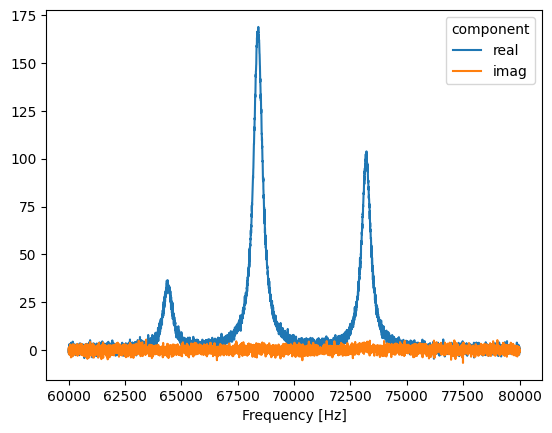

In [6]:
phased_da.xmr.to_real_imag().plot(hue='component')